# Evaluating FinBERT against the Baseline on the Held-out Test Split

Notebook 4 of 7. Every choice was fixed earlier on training and validation data: the baseline's grid search in notebook 2, FinBERT's checkpoint, settings and seed in notebook 3. This notebook computes test metrics exactly once, in one cell, for the fine-tuned FinBERT, the TF-IDF + Logistic Regression baseline and the ProsusAI reference, and compares them with the resume benchmarks: 93.4% accuracy, 0.91 macro F1 and a 19% relative accuracy gain over the baseline.

Outputs: `metrics_sentiment.json` (read by notebook 7 and the app) and `test_pred.parquet`.

## Setup

Imports and constants. `REPS` is the number of bootstrap resamples behind every 95% interval; the smoke run uses 200 to stay quick.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from scipy.stats import binomtest
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support

SMOKE = False
SEED = 42
REPS = 200 if SMOKE else 1000
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
LABELS = ["negative", "neutral", "positive"]
PROBS = ["p_neg", "p_neu", "p_pos"]
MODELS = {"finbert": "Fine-tuned FinBERT", "baseline": "TF-IDF + Logistic Regression", "prosus": "ProsusAI/finbert (trained on PhraseBank)"}
COLORS = {"finbert": "#2a78d6", "baseline": "#eda100", "prosus": "#52514e"}
SLICES = [("agreement >= 66%", 66), ("agreement >= 75%", 75), ("agreement = 100%", 100)]
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def accuracy(y, p):
    return float(np.mean(y == p))


def macro_f1(y, p):
    cm = np.zeros((3, 3), dtype=np.int64)
    np.add.at(cm, (y, p), 1)
    tp = np.diag(cm)
    denominator = 2 * tp + (cm.sum(axis=0) - tp) + (cm.sum(axis=1) - tp)
    return float(np.divide(2 * tp, denominator, out=np.zeros(3), where=denominator > 0).mean())


def summary(value, draws):
    low, high = np.percentile(draws, [2.5, 97.5])
    return {"value": float(value), "low": float(low), "high": float(high)}


def shown(result, percent=True):
    if percent:
        return f"{result['value']:.2%} [{result['low']:.2%}, {result['high']:.2%}]"
    return f"{result['value']:.4f} [{result['low']:.4f}, {result['high']:.4f}]"


print(f"smoke={SMOKE}, bootstrap resamples {REPS}")

smoke=False, bootstrap resamples 1000


**Conclusion.** The smoke switch is off, so every interval below rests on 1,000 bootstrap resamples.

## Inputs and the headline model

Loads the clean table, the three models' probabilities and the record of notebook 3's choice. The headline FinBERT is the seed notebook 3 picked on validation accuracy; the other two seeds only feed the spread reported below.

In [2]:
table = pd.read_parquet(find_file("phrasebank.parquet")).set_index("sentence_id")
best = json.loads(find_file("best_params.json").read_text(encoding="utf-8"))
fine = pd.read_parquet(find_file("finetune_pred.parquet"))
frames = {"finbert": fine[fine["seed"] == best["seed"]], "baseline": pd.read_parquet(find_file("baseline_pred.parquet")), "prosus": pd.read_parquet(find_file("prosus_pred.parquet"))}
print(f"headline FinBERT: {best['checkpoint']}, seed {best['seed']}, validation accuracy {best['val_accuracy'][str(best['seed'])]:.4f}")
print("settings: " + ", ".join(f"{k} {best[k]}" for k in ("lr", "epochs", "warmup", "weight_decay", "batch_size")))
for name, frame in frames.items():
    print(f"{MODELS[name]}: " + ", ".join(f"{split} {count}" for split, count in frame.groupby("split").size().items()))


def predicted(frame, split, ids):
    rows = frame[frame["split"] == split].set_index("sentence_id")
    return rows.loc[ids, PROBS].to_numpy().argmax(axis=1)

headline FinBERT: finbert-pretrain, seed 42, validation accuracy 0.8781
settings: lr 1.5574959668020445e-05, epochs 4, warmup 0.14526102468718302, weight_decay 0.009010581051148416, batch_size 32
Fine-tuned FinBERT: test 484, val 484
TF-IDF + Logistic Regression: test 484, val 484
ProsusAI/finbert (trained on PhraseBank): test 484, val 484


**Conclusion.** The headline FinBERT is notebook 3's seed 42, fine-tuned from finbert-pretrain with learning rate 1.56e-5, 4 epochs, 14.5% warmup, weight decay 0.009 and batch size 32. All three models have predictions for the same 484 validation and 484 test sentences.

## Validation recap

Validation accuracy of each model, already known from notebooks 2 and 3, printed again as the last look before the test split. It is not used for any decision here.

In [3]:
val = table[table["split"] == "val"]
for name, frame in frames.items():
    ids = frame.loc[frame["split"] == "val", "sentence_id"].to_numpy()
    print(f"{MODELS[name]}: validation accuracy {accuracy(table.loc[ids, 'label'].to_numpy(), predicted(frame, 'val', ids)):.4f} on {len(ids)} sentences")

Fine-tuned FinBERT: validation accuracy 0.8781 on 484 sentences
TF-IDF + Logistic Regression: validation accuracy 0.7996 on 484 sentences
ProsusAI/finbert (trained on PhraseBank): validation accuracy 0.8967 on 484 sentences


**Conclusion.** On validation the fine-tuned FinBERT scores 87.81%, the baseline 79.96% and the ProsusAI reference 89.67%, the figures notebooks 2 and 3 printed. Nothing here feeds a decision.

## The test evaluation

The only cell that computes test metrics. For each model: accuracy and macro F1 with 95% bootstrap intervals (test sentences resampled with replacement, seed 42), per-class precision, recall and F1, and the confusion matrix. Then the four readings of "outperforming the baseline", with the relative accuracy gain as the pre-registered headline and paired bootstrap intervals; the exact McNemar test on the sentences where exactly one of FinBERT and the baseline is right; the pre-declared agreement slices; the spread across the three seeds; and the benchmark table judged on the full test split, with the 100% agreement slice in its own labelled rows.

In [4]:
test = table[table["split"] == "test"]
ids = test.index.to_numpy()
y = test["label"].to_numpy()
preds = {name: predicted(frame, "test", ids) for name, frame in frames.items()}
for name, p in preds.items():
    assert np.isclose(macro_f1(y, p), f1_score(y, p, average="macro", labels=[0, 1, 2], zero_division=0))
rng = np.random.default_rng(SEED)


def bootstrap(mask):
    rows = np.flatnonzero(mask)
    draws = rng.integers(0, len(rows), size=(REPS, len(rows)))
    out = {name: np.empty((REPS, 2)) for name in preds}
    for r, d in enumerate(draws):
        chosen = rows[d]
        for name, p in preds.items():
            out[name][r] = accuracy(y[chosen], p[chosen]), macro_f1(y[chosen], p[chosen])
    return out


draws = bootstrap(np.ones(len(y), dtype=bool))
report = {}
for name, p in preds.items():
    precision, recall, f1, support = precision_recall_fscore_support(y, p, labels=[0, 1, 2], zero_division=0)
    report[name] = {
        "accuracy": summary(accuracy(y, p), draws[name][:, 0]),
        "macro_f1": summary(macro_f1(y, p), draws[name][:, 1]),
        "per_class": {LABELS[k]: {"precision": float(precision[k]), "recall": float(recall[k]), "f1": float(f1[k]), "support": int(support[k])} for k in range(3)},
        "confusion": confusion_matrix(y, p, labels=[0, 1, 2]).tolist(),
    }
ft, lr = draws["finbert"], draws["baseline"]
a_ft, f_ft = report["finbert"]["accuracy"]["value"], report["finbert"]["macro_f1"]["value"]
a_lr, f_lr = report["baseline"]["accuracy"]["value"], report["baseline"]["macro_f1"]["value"]
improvement = {
    "relative_accuracy": summary(a_ft / a_lr - 1, ft[:, 0] / lr[:, 0] - 1),
    "absolute_accuracy": summary(a_ft - a_lr, ft[:, 0] - lr[:, 0]),
    "relative_macro_f1": summary(f_ft / f_lr - 1, ft[:, 1] / lr[:, 1] - 1),
    "absolute_macro_f1": summary(f_ft - f_lr, ft[:, 1] - lr[:, 1]),
}
right_ft, right_lr = preds["finbert"] == y, preds["baseline"] == y
only_ft, only_lr = int(np.sum(right_ft & ~right_lr)), int(np.sum(~right_ft & right_lr))
mcnemar = {"finbert_only": only_ft, "baseline_only": only_lr, "p": float(binomtest(only_ft, only_ft + only_lr, 0.5).pvalue) if only_ft + only_lr else 1.0}
slices = []
for name, level in SLICES:
    mask = test["agreement"].to_numpy() >= level
    slice_draws = bootstrap(mask)
    slices.append({"name": name, "n": int(mask.sum()), "models": {m: {"accuracy": summary(accuracy(y[mask], p[mask]), slice_draws[m][:, 0]), "macro_f1": summary(macro_f1(y[mask], p[mask]), slice_draws[m][:, 1])} for m, p in preds.items()}})
seeds = []
for seed, rows in fine[fine["split"] == "test"].groupby("seed"):
    p = rows.set_index("sentence_id").loc[ids, PROBS].to_numpy().argmax(axis=1)
    seeds.append({"seed": int(seed), "val_accuracy": float(best["val_accuracy"][str(seed)]), "test_accuracy": accuracy(y, p), "test_macro_f1": macro_f1(y, p)})
seed_accuracy = {"mean": float(np.mean([s["test_accuracy"] for s in seeds])), "sd": float(np.std([s["test_accuracy"] for s in seeds], ddof=1))}


def bench(name, scope, target, result, fmt):
    return {"name": name, "scope": scope, "kind": "sentiment", "direction": ">=", "format": fmt, "target": target, "achieved": result["value"], "low": result["low"], "high": result["high"], "met": bool(result["value"] >= target)}


top = slices[-1]["models"]["finbert"]
benchmarks = [
    bench("Test accuracy", "full test split", 0.934, report["finbert"]["accuracy"], "percent"),
    bench("Test macro F1", "full test split", 0.91, report["finbert"]["macro_f1"], "decimal"),
    bench("Relative accuracy gain over TF-IDF + LR", "full test split", 0.19, improvement["relative_accuracy"], "percent"),
    bench("Test accuracy", "100% agreement slice", 0.934, top["accuracy"], "percent"),
    bench("Test macro F1", "100% agreement slice", 0.91, top["macro_f1"], "decimal"),
]
print(f"test sentences: {len(y)}")
for name in preds:
    print(f"{MODELS[name]}: accuracy {shown(report[name]['accuracy'])}, macro F1 {shown(report[name]['macro_f1'], False)}")
    for label, scores in report[name]["per_class"].items():
        print(f"    {label}: precision {scores['precision']:.4f}, recall {scores['recall']:.4f}, F1 {scores['f1']:.4f}, support {scores['support']}")
    print(f"    confusion (rows true, columns predicted; negative, neutral, positive): {report[name]['confusion']}")
print(f"relative accuracy gain (headline): {shown(improvement['relative_accuracy'])}")
print(f"absolute accuracy gain: {shown(improvement['absolute_accuracy'])} points")
print(f"relative macro F1 gain: {shown(improvement['relative_macro_f1'])}")
print(f"absolute macro F1 gain: {shown(improvement['absolute_macro_f1'], False)}")
print(f"McNemar exact test: FinBERT right and baseline wrong {only_ft}, the reverse {only_lr}, p = {mcnemar['p']:.3g}")
for item in slices:
    print(f"{item['name']} ({item['n']} sentences): " + "; ".join(f"{MODELS[m]} accuracy {shown(r['accuracy'])}, macro F1 {shown(r['macro_f1'], False)}" for m, r in item["models"].items()))
for s in seeds:
    print(f"seed {s['seed']}: validation {s['val_accuracy']:.4f}, test accuracy {s['test_accuracy']:.4f}, test macro F1 {s['test_macro_f1']:.4f}")
print(f"test accuracy across seeds: mean {seed_accuracy['mean']:.4f}, sd {seed_accuracy['sd']:.4f}")
for b in benchmarks:
    value = f"{b['achieved']:.2%}" if b["format"] == "percent" else f"{b['achieved']:.4f}"
    target = f"{b['target']:.1%}" if b["format"] == "percent" else f"{b['target']:.2f}"
    print(f"benchmark {b['name']} ({b['scope']}): target {target}, achieved {value}, interval [{b['low']:.4f}, {b['high']:.4f}], {'met' if b['met'] else 'missed'}")

test sentences: 484
Fine-tuned FinBERT: accuracy 83.47% [79.96%, 86.98%], macro F1 0.8215 [0.7826, 0.8586]
    negative: precision 0.8095, recall 0.8500, F1 0.8293, support 60
    neutral: precision 0.8706, recall 0.8646, F1 0.8676, support 288
    positive: precision 0.7704, recall 0.7647, F1 0.7675, support 136
    confusion (rows true, columns predicted; negative, neutral, positive): [[51, 7, 2], [10, 249, 29], [2, 30, 104]]
TF-IDF + Logistic Regression: accuracy 76.86% [72.93%, 80.58%], macro F1 0.7325 [0.6838, 0.7792]
    negative: precision 0.7407, recall 0.6667, F1 0.7018, support 60
    neutral: precision 0.8100, recall 0.8438, F1 0.8265, support 288
    positive: precision 0.6846, recall 0.6544, F1 0.6692, support 136
    confusion (rows true, columns predicted; negative, neutral, positive): [[40, 14, 6], [10, 243, 35], [4, 43, 89]]
ProsusAI/finbert (trained on PhraseBank): accuracy 88.64% [85.74%, 91.32%], macro F1 0.8772 [0.8430, 0.9074]
    negative: precision 0.7945, recal

**Conclusion.** The fine-tuned FinBERT reaches 83.47% test accuracy (95% interval 79.96% to 86.98%) and 0.8215 macro F1, against 76.86% and 0.7325 for the tuned TF-IDF + Logistic Regression baseline. The pre-registered reading, the relative accuracy gain, is 8.60% (3.12% to 14.41%); in absolute terms the gain is 6.61 points, and on macro F1 it is 12.15% relative or 0.089 absolute. The McNemar test confirms the gap is real: FinBERT is right where the baseline is wrong on 65 sentences and the reverse holds on 33, p = 0.0016. All three benchmarks on the full test split are missed, accuracy by 9.9 points, macro F1 by 0.089 and the relative gain by 10.4 points, and even the upper ends of the intervals (86.98%, 0.8586, 14.41%) fall short. The agreement slices show where the difficulty lies: accuracy rises from 83.47% on all sentences to 88.15% at 66% agreement or more, 93.06% at 75% or more and 96.46% at full agreement, where both benchmarks are met (96.46% accuracy, macro F1 0.9524). That matches the published FinBERT pattern of 0.86 on all data and 0.97 at full agreement. The ProsusAI checkpoint scores 88.64%; that it beats a model fine-tuned on this exact training split by 5 points is consistent with it having seen these test sentences in training. Across the three seeds test accuracy averages 82.64% with a standard deviation of 0.72 points, so the headline seed is not a lucky outlier. FinBERT's errors sit mostly between neutral and positive (29 neutral sentences called positive, 30 positive called neutral), while negatives are recognised well (recall 0.85).

## Figures

Plots the numbers above without computing anything new: the confusion matrices of the three models, accuracy with 95% intervals on the full test split and on each agreement slice, and per-class F1.

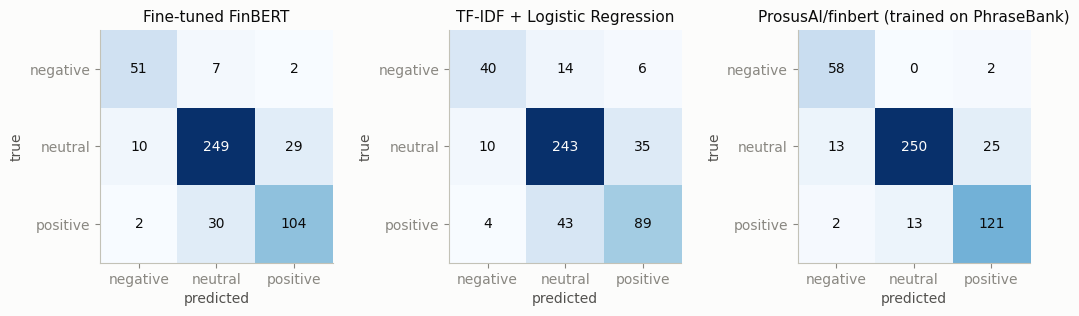

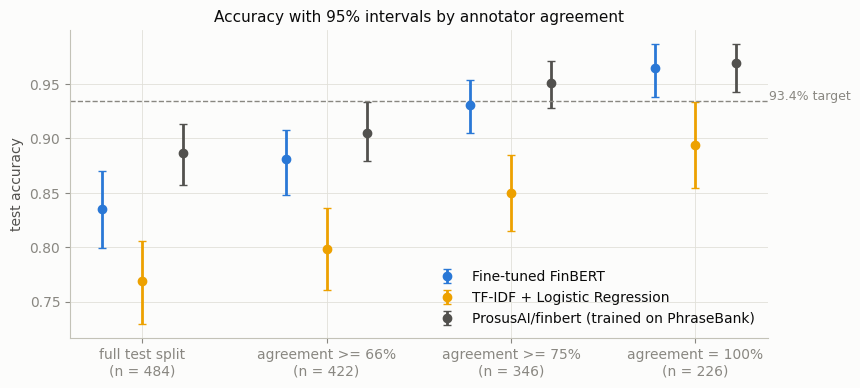

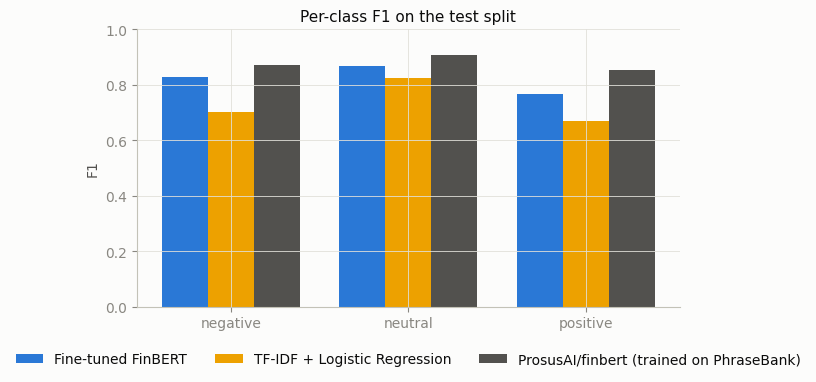

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, name in zip(axes, preds):
    cm = np.array(report[name]["confusion"])
    ax.imshow(cm, cmap="Blues")
    ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center", color=INK if cm[i, j] < cm.max() * 0.6 else SURFACE)
    ax.set_xticks(range(3), LABELS)
    ax.set_yticks(range(3), LABELS)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(MODELS[name])
fig.subplots_adjust(wspace=0.5)
save(fig, "confusion")
groups = [("full test split", {m: report[m]["accuracy"] for m in preds}, len(y))] + [(s["name"], {m: r["accuracy"] for m, r in s["models"].items()}, s["n"]) for s in slices]
fig, ax = plt.subplots(figsize=(9, 4))
for i, name in enumerate(preds):
    x = np.arange(len(groups)) + (i - 1) * 0.22
    values = [g[1][name]["value"] for g in groups]
    errors = [[g[1][name]["value"] - g[1][name]["low"] for g in groups], [g[1][name]["high"] - g[1][name]["value"] for g in groups]]
    ax.errorbar(x, values, yerr=errors, fmt="o", color=COLORS[name], capsize=3, label=MODELS[name])
ax.axhline(0.934, color=MUTED, linestyle="--", linewidth=1)
ax.text(len(groups) - 0.6, 0.936, "93.4% target", color=MUTED, fontsize=9)
ax.set_xticks(range(len(groups)), [f"{g[0]}\n(n = {g[2]})" for g in groups])
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy with 95% intervals by annotator agreement")
ax.legend(loc="lower right")
save(fig, "accuracy_by_slice")
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, name in enumerate(preds):
    ax.bar(np.arange(3) + (i - 1) * 0.26, [report[name]["per_class"][l]["f1"] for l in LABELS], width=0.26, color=COLORS[name], label=MODELS[name])
ax.set_xticks(range(3), LABELS)
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.set_title("Per-class F1 on the test split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
save(fig, "per_class_f1")

**Conclusion.** The first figure shows accuracy climbing with annotator agreement for all three models: the fine-tuned FinBERT clears the 93.4% line only at full agreement (its interval at 75% or more straddles it), and the baseline sits below FinBERT on every slice. The confusion matrices show neutral against positive as the main confusion for every model, and per-class F1 makes positive the hardest class (FinBERT 0.77, baseline 0.67).

## Outputs

Writes the metrics, including the benchmark rows, for notebook 7 and the app, and every model's test predictions for traceability.

In [6]:
counts = {split: int((table["split"] == split).sum()) for split in ("train", "val", "test")}
metrics = {"checkpoint": best["checkpoint"], "chosen_seed": best["seed"], "counts": counts, "models": report, "improvement": improvement, "mcnemar": mcnemar, "slices": slices, "seeds": seeds, "seed_accuracy": seed_accuracy, "benchmarks": benchmarks}
(OUT / "metrics_sentiment.json").write_text(json.dumps(metrics, indent=2, allow_nan=False), encoding="utf-8")
pd.DataFrame({"sentence_id": ids, "label": y, "agreement": test["agreement"].to_numpy(), **{f"pred_{name}": p for name, p in preds.items()}}).to_parquet(OUT / "test_pred.parquet", index=False)
print(f"metrics_sentiment.json: {(OUT / 'metrics_sentiment.json').stat().st_size / 1e3:.1f} kB; test_pred.parquet: {len(ids)} rows")
print(f"elapsed {(time.time() - START) / 60:.1f} minutes")

metrics_sentiment.json: 9.5 kB; test_pred.parquet: 484 rows
elapsed 0.0 minutes


**Conclusion.** The metrics, with five benchmark rows (three missed on the full test split, two met on the full-agreement slice), are written for notebook 7 and the app, and every model's test predictions are kept for traceability.